In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Linear Regression

In this lab, we are going to implement a Linear Regression model "by hand" and also use sklearn to implement linear regressors using different basis functions, and then add regularization to the models.



## Part 1 - Synthetic and real datasets

* Generate 50 points in a line in the interval $[0, 10]$ for `x`, perturbed by a small gaussian noise. For example, `y = 2 * x + 5 + noise` where `noise` is taken from a normal distribution.
* plot the generated data as a scatter plot, and the line without noise as a reference

*Note:* If you want to generate the same data as I generated, use $y = 3x + 5 + \epsilon$ after setting the random seed to 0

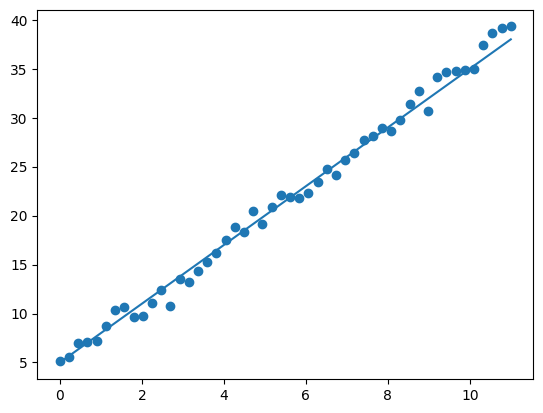

In [4]:
# your code here
rng=np.random.default_rng(0)
x=np.linspace(0,11,50)
noise=rng.normal(0,1,50)
y=3*x+5
y_noise=y+noise
plt.scatter(x,y_noise)
plt.plot(x,y)

plt.show()

### Load the housing dataset

For this lab we will be using the raw version of the Housing dataset.

**Housing.txt:** this dataset is constituted by 506 points in 14 dimensions. Each point represents a house in the Boston area, and the 14 attributes that you find orderly in each column are the following:
* `CRIM` - per capita crime rate by town
* `ZN` - proportion of residential land zoned for lots over 25,000 sq.ft.
* `INDUS` - proportion of non-retail business acres per town.
* `CHAS` - Charles River dummy variable (1 if tract bounds river; 0 otherwise) 
* `NOX` - nitric oxides concentration (parts per 10 million)
* `RM` - average number of rooms per dwelling
* `AGE` - proportion of owner-occupied units built prior to 1940
* `DIS` - weighted distances to five Boston employment centres
* `RAD` - index of accessibility to radial highways
* `TAX` - full-value property-tax rate per \$10,000
* `PTRATIO` - pupil-teacher ratio by town
* `B` - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
* `LSTAT` - % lower status of the population
* `MEDV` - Median value of owner-occupied homes in $1000's

This dataset is normally associated with 2 regression tasks: predicting `NOX` (in which the nitrous oxide level is to be predicted); and predicting price `MEDV` (in which the median value of a home is to be predicted).

In [5]:
housing_names = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]
housing = pd.read_table("data/housing.txt", names=housing_names, sep='\s+')
housing=(housing-housing.mean())/housing.std()
housing

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Edilson\AppData\Local\Temp\ipykernel_2112\1438242658.py:2: SyntaxWarning: invalid escape sequence '\s'
  housing = pd.read_table("data/housing.txt", names=housing_names, sep='\s+')


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,-0.419367,0.284548,-1.286636,-0.272329,-0.144075,0.413263,-0.119895,0.140075,-0.981871,-0.665949,-1.457558,0.440616,-1.074499,0.159528
1,-0.416927,-0.487240,-0.592794,-0.272329,-0.739530,0.194082,0.366803,0.556609,-0.867024,-0.986353,-0.302794,0.440616,-0.491953,-0.101424
2,-0.416929,-0.487240,-0.592794,-0.272329,-0.739530,1.281446,-0.265549,0.556609,-0.867024,-0.986353,-0.302794,0.396035,-1.207532,1.322937
3,-0.416338,-0.487240,-1.305586,-0.272329,-0.834458,1.015298,-0.809088,1.076671,-0.752178,-1.105022,0.112920,0.415751,-1.360171,1.181589
4,-0.412074,-0.487240,-1.305586,-0.272329,-0.834458,1.227362,-0.510674,1.076671,-0.752178,-1.105022,0.112920,0.440616,-1.025487,1.486032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,-0.412820,-0.487240,0.115624,-0.272329,0.157968,0.438881,0.018654,-0.625178,-0.981871,-0.802418,1.175303,0.386834,-0.417734,-0.014440
502,-0.414839,-0.487240,0.115624,-0.272329,0.157968,-0.234316,0.288648,-0.715931,-0.981871,-0.802418,1.175303,0.440616,-0.500355,-0.210154
503,-0.413038,-0.487240,0.115624,-0.272329,0.157968,0.983986,0.796661,-0.772919,-0.981871,-0.802418,1.175303,0.440616,-0.982076,0.148655
504,-0.407361,-0.487240,0.115624,-0.272329,0.157968,0.724955,0.736268,-0.667776,-0.981871,-0.802418,1.175303,0.402826,-0.864446,-0.057932


## Part 2 -- Build Linear Regression Models

You will need to implement it twice:

1. using the Normal Equations seen in class (Moore-Penrose pseudo-inverse)
2. using stochastic gradient descent

* **Tip 1:** When you implement the stochastic gradient version it will be crucial to plot the sum of squares error as a function of the iteration
* **Tip 2:** You will need to initialize the weights. Start by choosing them randomly, Gaussian distributed, with a very small variance...

Run some experiments with your stochastic gradient descent version, and think about these questions: 
* what happens with different values of the step parameter? 
* Does the system always converge to the same solution? 
* Are you getting the same solution that you get with the closed form implementation? 
* What happens if you initialize your weights to values that are too big?

Below, I provide some skeletons for your implementations, but feel free to structure your code differently.

Remember to:
* Separate the datasets into training and testing (I used 60% for training)


In [24]:
def linear_regression_PI(X, y):
    """
    Implements a Linear Regression model using the Moore-Penrose pseudo-inverse
    
    Parameters
    ----------
    X : array
        A 2-dimensional array with samples in the rows and features in the columns
    y : array
        An array with the same number of  as samples in X, the values to predict
    
    Returns
    -------
    w : array
        Learnt parameters
        
    Notes
    -----
    The first column of w corresponds to the bias (`w_0`)
    """
    # your code here

    M=X.shape[1]
    N=y.size
    fi=np.zeros(shape=(N,M+1))
    fi[:,0]=np.ones_like(X[:,0])
    fi[:,1:]=X
    w=np.linalg.solve(fi.T@fi,fi.T@y)
    return w
    


def linear_regression_SGD(X, y, lr, max_iter=10):
    """
    Implements a Linear Regression model using Stochastic Gradient Descent
    
    Parameters
    ----------
    X : array
        A 2-dimensional array with samples in the rows and features in the columns
    y : array
        An array with the same number of  as samples in X, the values to predict
    lr : float
        Learning rate
    max_iter : int
        number of epochs to use for the gradient descent
    
    Returns
    -------
    w : array
        Learnt parameters
    sse_history : array
        An array that contains the error of the model in every iteration
    Notes
    -----
    This function uses the gradient of the sum of squares function (Equations 3.12, and 3.23 in the Bishop book)
    """
    # your code here
    M=X.shape[1]
    N=y.size
    fi=np.zeros(shape=(N,M+1))
    fi[:,0]=np.ones_like(X[:,0])
    fi[:,1:]=X
    w=np.random.rand(X.shape[1]+1)
    for i in range(max_iter):
        w=w+lr*(fi.T)@(y-fi@w)
    return w


we can now use this function to learn the parameters for predicting `NOX`

First you will have to prepare the data:
- Separate the features from the target variables (Put the features in a matrix X and the target variable in a vector y)
- Split the data using sklearn's train_test_split.

In [25]:
# your code here
housing_names = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]
housing = pd.read_table("data/housing.txt", names=housing_names, sep='\s+')
housing=(housing-housing.mean())/housing.std()
from sklearn.model_selection import train_test_split
y=np.array(housing["NOX"].copy())
housing=housing.drop(["NOX"],axis=1)
X=np.array(housing)
X_train,X_test,y_train,y_test=train_test_split(X,y)


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Edilson\AppData\Local\Temp\ipykernel_2112\10959510.py:3: SyntaxWarning: invalid escape sequence '\s'
  housing = pd.read_table("data/housing.txt", names=housing_names, sep='\s+')


Now use the functions you coded to learn the weights!

In [26]:
# your code here
w_pi=linear_regression_PI(X_test,y_test)
w_sgd=linear_regression_SGD(X_test,y_test,0.001,600)


make a plot that shows the evolution of the sum of squares error

**tip:** make it a callable function that you can reuse for the next task

In [111]:
# your code here
import matplotlib.pyplot as plt
def plot_errors(X,y,lr,max_iter):
    M=X.shape[1]
    N=y.size
    fi=np.zeros(shape=(N,M+1))
    fi[:,0]=np.ones_like(X[:,0])
    fi[:,1:]=X
    w=np.zeros(X.shape[1]+1)
    errors=[]
    for i in range(max_iter):
        w=w+lr*(fi.T)@(y-fi@w)
        errors.append((np.sum((y-fi@w)**2))/2)
    plt.plot(errors)
    plt.xlim(0,max_iter)
    plt.ylim(0)
    plt.show()


Use the learn weights to make predictions for the test set, and evaluate the model using the root mean squared error (remember that the bias is the first column of the weight matrix)
- You can use the function you coded for your coursework, but feel free to use sklearn's `mean_squared_error()` here

In [10]:
# your code here
from sklearn.metrics import mean_squared_error
y_pred_pi=w_pi[0]+X_test@w_pi[1:]
y_pred_sgd=w_sgd[0]+X_test@w_pi[1:]
def mse(y_real,y_pred):
    return ((y_real-y_pred)**2).sum()/y_pred.size
print(mse(y_test,y_pred_pi))
print(mse(y_test,y_pred_sgd))


0.19972379159109815
0.19972380239148868


Repeat the same analysis for predicting `MEDV`

In [112]:
# your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
housing_names = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]
housing = pd.read_table("data/housing.txt", names=housing_names, sep='\s+')
housing=(housing-housing.mean())/housing.std()
from sklearn.model_selection import train_test_split
y=np.array(housing["NOX"].copy())
housing=housing.drop(["NOX"],axis=1)
housing=housing.drop(["MEDV"],axis=1)
X=np.array(housing)
X_train,X_test,y_train,y_test=train_test_split(X,y)

w_pi=linear_regression_PI(X_test,y_test)
w_sgd=linear_regression_SGD(X_test,y_test,0.001,600)

def plot_errors(X,y,lr,max_iter):
    M=X.shape[1]
    N=y.size
    fi=np.zeros(shape=(N,M+1))
    fi[:,0]=np.ones_like(X[:,0])
    fi[:,1:]=X
    w=np.zeros(X.shape[1]+1)
    errors=[]
    for i in range(max_iter):
        w=w+lr*(fi.T)@(y-fi@w)
        errors.append((np.sum((y-fi@w)**2))/2)
    plt.plot(errors)
    plt.xlim(0,max_iter)
    plt.ylim(0)
    plt.show()
plot_errors(X_test,y_test,0.001,100)

from sklearn.metrics import mean_squared_error
y_pred_pi=w_pi[0]+X_test@w_pi[1:]
y_pred_sgd=w_sgd[0]+X_test@w_pi[1:]
def mse(y_real,y_pred):
    return ((y_real-y_pred)**2).sum()/y_pred.size
print(mse(y_test,y_pred_pi))
print(mse(y_test,y_pred_sgd))

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Edilson\AppData\Local\Temp\ipykernel_6664\1530473777.py:6: SyntaxWarning: invalid escape sequence '\s'
  housing = pd.read_table("data/housing.txt", names=housing_names, sep='\s+')
C:\Users\Edilson\AppData\Local\Temp\ipykernel_6664\1530473777.py:6: SyntaxWarning: invalid escape sequence '\s'
  housing = pd.read_table("data/housing.txt", names=housing_names, sep='\s+')


FileNotFoundError: [Errno 2] No such file or directory: 'data/housing.txt'

## Part 3 - Polynomial basis function

* Generate a 2D dataset using a sine wave (10 values for `x` in the interval $[0, 10]$), perturbed by a small gaussian noise. *Note:* To generate the same data as I generated, use $y = 4sin(x) + \epsilon$ by setting the seed to 0
* The Polynomial basis function that you will use is of the following form:
    - $\phi_i(x)=x^i$
* You will do this to create models of degrees 2, 4, and 9.
    - Transform your original `x` into the design matrix $\Phi$ by applying the basis functions to each element of `x`
    - For degree 2: $i\in[0,1,2]$, for degree 4: $i\in[0,1,2,3,4]$, and for degree 9: $i\in[0,1,2,...,9]$
    - *This means that for each Degree you will create a different $\Phi$ and fit a different regression model.*

* Plot the data and the prediction for each degree.
* Which degree of polynomial works better to model this scenario? 

Example: Let's say that $$x=\begin{bmatrix} x_1=2 \\ x_2=3 \\ x_3=1 \end{bmatrix}$$
Then for Degree 2 I will use the following basis functions: $\phi_0(x_j)=x_j^0, \phi_1(x_j)=x_j^1, \phi_2(x_j)=x_j^2$.

In this case, $\Phi$ will look like: 
$$\Phi=\begin{bmatrix} \phi_0(x_1)=x_1^0 & \phi_1(x_1)=x_1^1 & \phi_2(x_1)=x_1^2 \\ \phi_0(x_2)=x_2^0 & \phi_1(x_2)=x_2^1 & \phi_2(x_2)=x_2^2 \\ \phi_0(x_3)=x_3^0 & \phi_1(x_3)=x_3^1 & \phi_2(x_3)=x_3^2 \end{bmatrix}$$

Finally:
$$\Phi=\begin{bmatrix} 1 & 2 & 4 \\ 1 & 3 & 9 \\ 1 & 1 & 1 \end{bmatrix}$$

__*Important:* You have to code this exercise yourself.__



AQUI Ó


In [251]:
import numpy as np

m=20
d=5

def mse(y_real,y_pred):
    return ((y_real-y_pred)**2).sum()/y_pred.size

def calculate_phi(x,degree):
    fi=np.zeros((x.size,degree+1))
    fi[:,0]=np.ones(x.size)
    for i in range(1,fi.shape[1]):
        fi[:,i]=x**i
    return fi


def lr_pi_pol(x,y_noise,degree):
    fi=np.zeros((x.size,degree+1))
    fi[:,0]=np.ones(x.size)
    for i in range(1,fi.shape[1]):
        fi[:,i]=x**i
    w=np.linalg.solve(fi.T@fi,fi.T@y_noise)
    return w,fi,np.linalg.pinv(fi)


from sklearn.model_selection import train_test_split
x=np.sort(rng.uniform(-1,1,m))
noise=rng.normal(-1,1,m)
b=np.sin(x)+noise
x_train,x_test,b_train,b_test=train_test_split(x,b)



def basis_lagrange(x,y,d):
    basis=np.ones((x.shape[0],d))
    denominator=1
    numerator=1
    for column in range(d):
        for j in range(len(x)):
            for i in range(len(x)):
                if column!=i:
                    basis[j,column]*=(y[j]-x[i])/(x[column]-x[i])
    return basis


def lr_lagrange(x,y_noise,degree):
    fi=basis_lagrange(x,x,degree)
    w=np.linalg.solve(fi.T@fi,fi.T@y_noise)
    return w,fi,np.linalg.pinv(fi)

w,lx,rx=lr_pi_pol(x_train,b_train,d)
print("condicionamento base canonica: ", np.linalg.cond(lx))


b_pred_base_canonica=calculate_phi(x_test,d)@w
print("erro base canonica: ",mse(b_test,b_pred_base_canonica))

w,lx,rx=lr_lagrange(x_train,b_train,d)
print("condicionamento lagrange: ", np.linalg.cond(lx))


b_pred_lagrange=basis_lagrange(x_test,x_test,d)@w
print("erro lagrange: ", mse(b_test,b_pred_lagrange))

condicionamento base canonica:  69.35216578571492
erro base canonica:  0.3155575553153115
condicionamento lagrange:  1.0
erro lagrange:  0.46133662033218314


In [4]:
# your code here
from scipy.interpolate import make_interp_spline
rng=np.random.default_rng(0)
x=np.sort(rng.uniform(0,10,11))
noise=rng.normal(0,1,11)

y=4*np.sin(x)

y_noise=y+noise

def lr_pi_pol(x,y_noise,degree):
    fi=np.zeros((x.size,degree+1))
    fi[:,0]=np.ones(x.size)
    for i in range(1,fi.shape[1]):
        fi[:,i]=x**i
    w=np.linalg.solve(fi.T@fi,fi.T@y_noise)
    return w



w_2=lr_pi_pol(x[:9],y_noise[:9],2)
w_4=lr_pi_pol(x[:9],y_noise[:9],4)
w_9=lr_pi_pol(x[:9],y_noise[:9],9)

w_5=lr_pi_pol(x[:9],y_noise[:9],5)

def test(x,degree):
    fi=np.zeros((x.size,degree+1))
    fi[:,0]=np.ones(x.size)
    for i in range(1,fi.shape[1]):
        fi[:,i]=x**i
    return fi

fi_test=[1]
for i in range(1,3):
    fi_test.append(x[10]**i)
fi_test=np.array(fi_test)
y_predict2=fi_test@w_2

fi_test=[1]
for i in range(1,5):
    fi_test.append(x[10]**i)
fi_test=np.array(fi_test)
y_predict4=fi_test@w_4

fi_test=[1]
for i in range(1,10):
    fi_test.append(x[10]**i)
fi_test=np.array(fi_test)
y_predict9=fi_test@w_9

fi_test=[1]
for i in range(1,6):
    fi_test.append(x[10]**i)
fi_test=np.array(fi_test)
y_predict5=fi_test@w_5

y_pred_2=test(x[:9],2)@w_2
y_pred_4=test(x[:9],4)@w_4
y_pred_9=test(x[:9],9)@w_9

x_plot=np.linspace(x.min(),x.max(),300)
x_9plot=np.linspace(x[:9].min(),x[:9].max(),300)
spl = make_interp_spline(x, y)
y_smooth = spl(x_plot)

spl_2 = make_interp_spline(x[:9], y_pred_2)
y_2 = spl_2(x_9plot)

spl_4 = make_interp_spline(x[:9], y_pred_4)
y_4 = spl_4(x_9plot)

spl_9 = make_interp_spline(x[:9], y_pred_9)
y_9 = spl_9(x_9plot)


plt.plot(x_9plot,y_2,label="grau 2",color="orange")
plt.plot(x_9plot,y_4,label="grau 4",color="green")
plt.plot(x_9plot,y_9,label="grau 9",color="red")

plt.scatter(x,y_noise, label="pontos reais")

plt.scatter(x[10],y_predict2,color="orange",label="11ºponto grau 2")
plt.scatter(x[10],y_predict4,color="green",label="11ºponto grau 4")
plt.legend()
plt.xlim(0)
plt.show()
#como podemos ver o grau 9 se aproxima mais da função original como esperado,
#porém, ao acrescentar um novo ponto, observamos que o grau 9 tem o maior erro, devido ao overfitting:
plt.plot(x_9plot,y_2,label="grau 2",color="orange")
plt.plot(x_9plot,y_4,label="grau 4",color="green")
plt.plot(x_9plot,y_9,label="grau 9",color="red")

plt.scatter(x,y_noise, label="pontos reais")

plt.scatter(x[10],y_predict2,color="orange",label="11ºponto grau 2")
plt.scatter(x[10],y_predict4,color="green",label="11ºponto grau 4")
plt.scatter(x[10],y_predict9,color="red",label="11ºponto grau 9")
plt.legend()
plt.xlim(0)

plt.show()
#dessa forma, o grau 4 é a melhor opção entre essas

NameError: name 'plt' is not defined

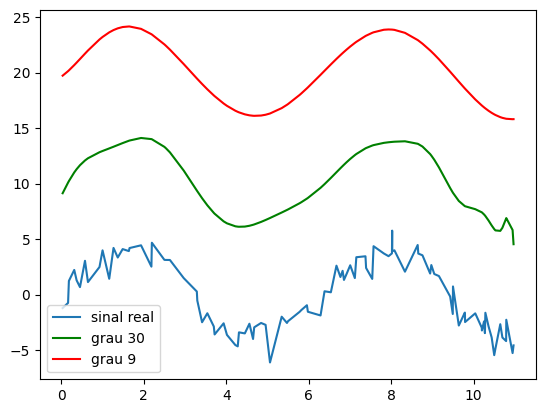

In [13]:
#aqui tem um exemplo do grau 9 apresentando melhores resultados, ao utilizar 100 pontos ao invés de 10. Ainda, podemos comparar com o grau 30 e
#perceber o overfitting novamente
rng=np.random.default_rng(0)
x=np.sort(rng.uniform(0,11,100))
noise=rng.normal(0,1,100)
y=4*np.sin(x)
y_noise=y+noise
plt.plot(x,y_noise,label="sinal real")


def leave_one_out(x,y_noise,degree):
    errors=[]
    for n in range(x.size):
        #training
        x_train=np.delete(x,n)
        y_train=np.delete(y_noise,n)
        x_test=x[n]
        y_test=y_noise[n]
        
        fi=np.zeros((x_train.size,degree+1))
        fi[:,0]=np.ones(x_train.size)
        for i in range(1,fi.shape[1]):
            fi[:,i]=x_train**i
        w=np.linalg.pinv(fi)@y_train

        #testing
        fi_test=[1]
        for i in range(1,degree+1):
            fi_test.append(x_test**i)
        fi_test=np.array(fi_test)
        y_pred=fi_test@w
        errors.append((y_test-y_pred)**2)
    return np.mean(errors)

w_30=lr_pi_pol(x,y_noise,30)
predict30=test(x,30)@w_30+10
w_9=lr_pi_pol(x,y_noise,9)
predict9=test(x,9)@w_9+20
plt.plot(x,predict30,color="green",label="grau 30")
plt.plot(x,predict9,color="red",label="grau 9")
plt.legend()
plt.show()

## Part 4 - Polynomial basis function

For this part you will replicate the previous part but using the existing functions from sklearn!

* Use the same data as the previous part.
* Use sklearn's Linear Regression estimator together with a Polynomial transform to make a Linear regression with a polynomial basis.

*Note:* To generate the same data as I generated, use $y = 4sin(x) + \epsilon$ by setting the seed to 0

[[10.28579666]]


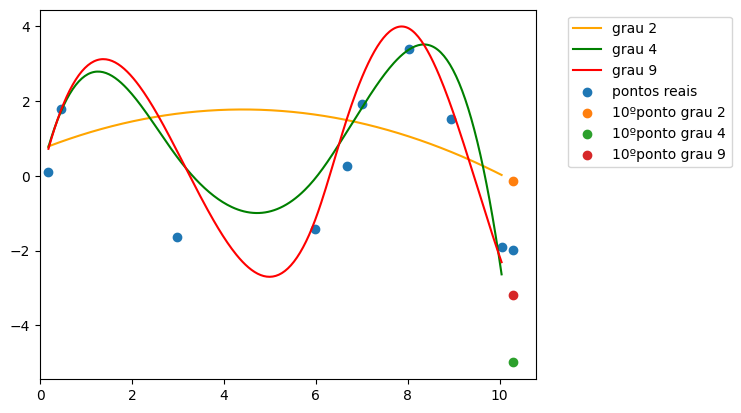

In [39]:
# your code here
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


rng = np.random.default_rng(0)
x = np.sort(rng.uniform(0,11,10))
noise = rng.normal(0,1,10)
y = 4*np.sin(x)
y_noise=y+noise
X = x.reshape(-1,1)


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0,test_size=0.1,shuffle=False)
print(X_test)
poly2=PolynomialFeatures(degree=2)
poly4=PolynomialFeatures(degree=4)
poly9=PolynomialFeatures(degree=9)
x_train2=poly2.fit_transform(X_train)
x_test2=poly2.transform(X_test)
x_train4=poly4.fit_transform(X_train)
x_test4=poly4.transform(X_test)
x_train9=poly9.fit_transform(X_train)
x_test9=poly9.transform(X_test)
model2=LinearRegression()
model4=LinearRegression()
model9=LinearRegression()
model2.fit(x_train2,y_train)
model4.fit(x_train4,y_train)
model9.fit(x_train9,y_train)
y_2=model2.predict(x_train2)
y_4=model4.predict(x_train4)
y_9=model9.predict(x_train9)

y_predict2=model2.predict(x_test2)
y_predict4=model4.predict(x_test4)
y_predict9=model9.predict(x_test9)

#só ta deixando bonito lindo maravilhoso, ignore
x_plot=np.linspace(x.min(),x.max(),300)
x_9plot=np.linspace(x[:9].min(),x[:9].max(),300)
spl = make_interp_spline(x, y)
y_smooth = spl(x_plot)

spl_2 = make_interp_spline(x[:9], y_2)
y_2 = spl_2(x_9plot)

spl_4 = make_interp_spline(x[:9], y_4)
y_4 = spl_4(x_9plot)

spl_9 = make_interp_spline(x[:9], y_9)
y_9 = spl_9(x_9plot)

#plot começa aqui
plt.plot(x_9plot,y_2,label="grau 2",color="orange")
plt.plot(x_9plot,y_4,label="grau 4",color="green")
plt.plot(x_9plot,y_9,label="grau 9",color="red")

plt.scatter(x,y_noise, label="pontos reais")
plt.scatter(x[9],y_predict2,label="10ºponto grau 2")
plt.scatter(x[9],y_predict4,label="10ºponto grau 4")
plt.scatter(x[9],y_predict9,label="10ºponto grau 9")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlim(0)
plt.show()

